# Logical H and S Gates — Fold-Transversal

Fold-transversal gates exploit the geometric symmetry of the unrotated surface code.
A **fold** maps each qubit to its mirror image across the patch diagonal, composing
physical SWAP gates with a transversal single-qubit gate to implement a logical Clifford.

- **H gate**: fold along the main diagonal, apply transversal H to all data qubits.
- **S gate**: fold along the anti-diagonal, apply transversal S.  
  Verified via the S-roundtrip circuit: prepare |+⟩, apply S (noisy), apply S† (noiseless), measure X.

Both circuits: init → SE rounds → gate → SE rounds → readout.

In [1]:
import sys
from pathlib import Path
import io, contextlib

ROOT = Path("../..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from lightstim.protocols.fold_transversal import (
    build_gate_verification_circuit,
    build_s_roundtrip_circuit,
)
from lightstim.noise.config import NoiseConfig
from lightstim.simulation.decoder_backend import SimulationPipeline, DecoderConfig

In [2]:
d = 3
p = 1e-3
rounds = 2
noise_params = NoiseConfig(p_idle=p, p_1q=p, p_2q=p, p_meas=p, p_reset=p)

## 1. H Gate Circuit

Two sub-experiments verifying the CNOT action on logical bases:
- `H_ZtoX`: prepare |0⟩_L (Z-basis), apply H, measure X-basis → expect +1.
- `H_XtoZ`: prepare |+⟩_L (X-basis), apply H, measure Z-basis → expect +1.

In [3]:
with contextlib.redirect_stdout(io.StringIO()):
    circuit_H_ZtoX = build_gate_verification_circuit(
        d, ["fold_transversal_hadamard"], init_basis="Z", measure_basis="X",
        rounds=rounds, unencode=False, noise_params=noise_params,
    )
    circuit_H_XtoZ = build_gate_verification_circuit(
        d, ["fold_transversal_hadamard"], init_basis="X", measure_basis="Z",
        rounds=rounds, unencode=False, noise_params=noise_params,
    )

print(f"H (Z→X): {circuit_H_ZtoX.num_qubits} qubits, {circuit_H_ZtoX.num_detectors} detectors")
print(f"H (X→Z): {circuit_H_XtoZ.num_qubits} qubits, {circuit_H_XtoZ.num_detectors} detectors")

H (Z→X): 25 qubits, 48 detectors
H (X→Z): 25 qubits, 48 detectors


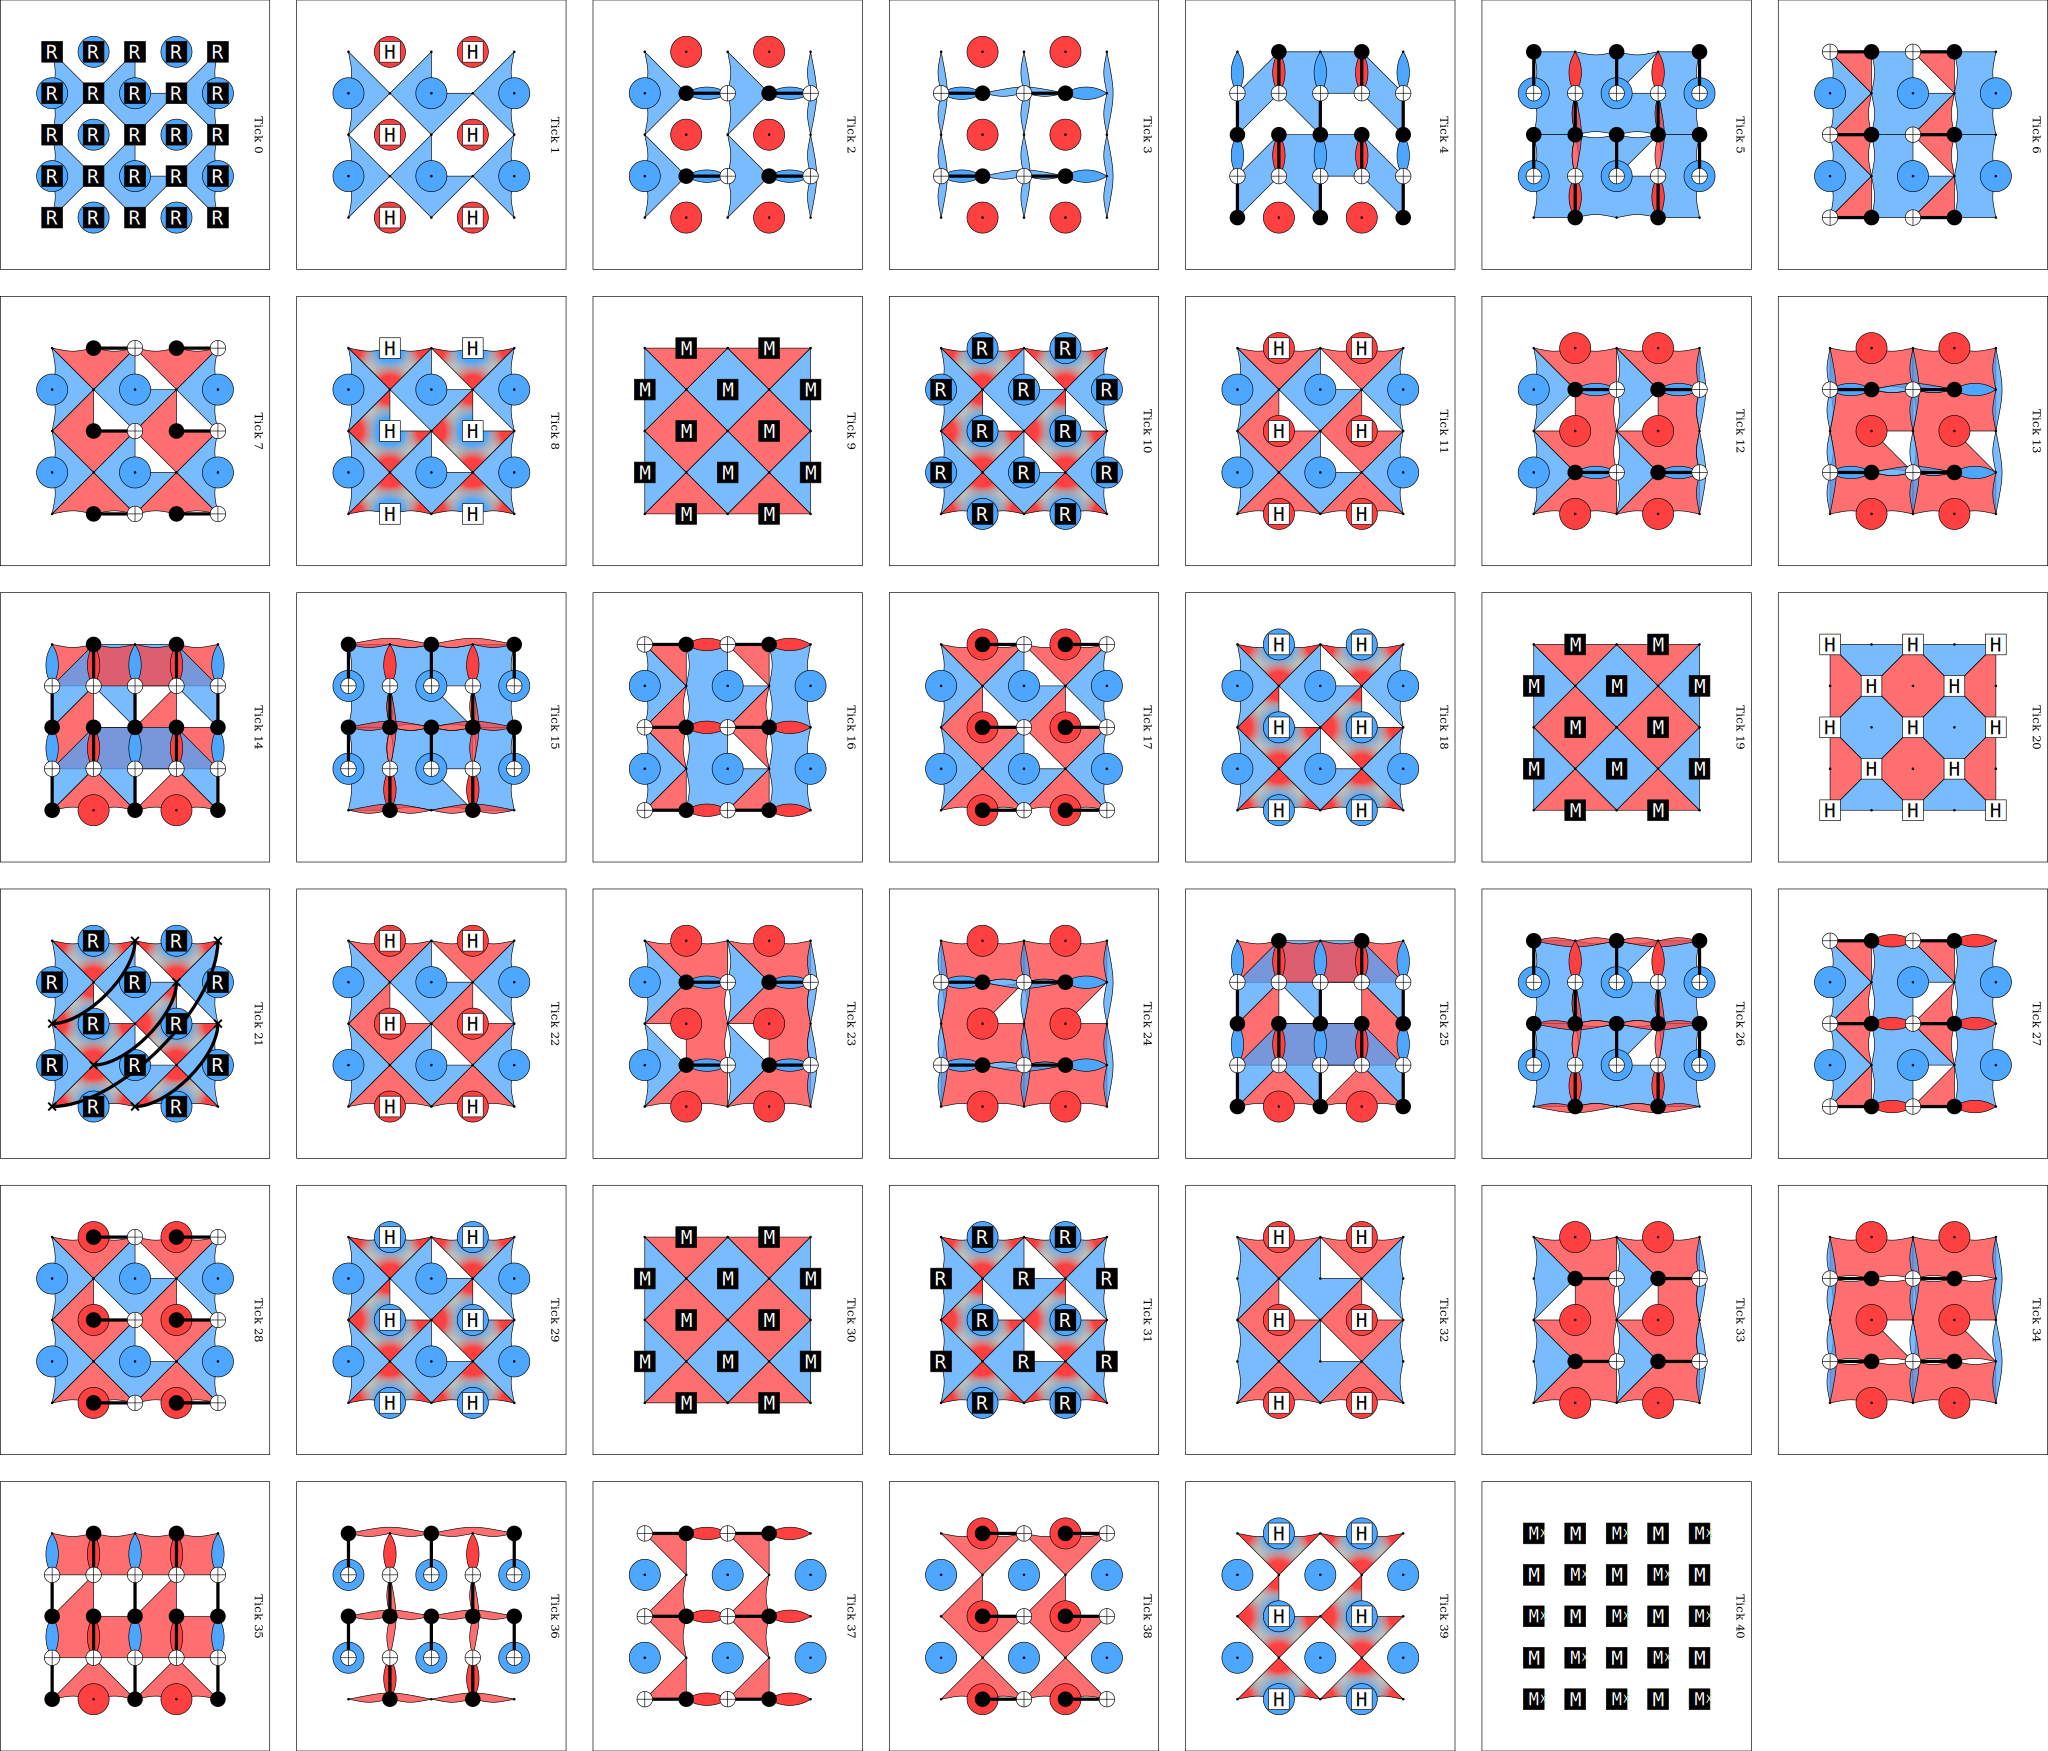

In [4]:
circuit_H_ZtoX.without_noise().diagram("detslice-with-ops-svg")

## 2. S Gate Circuit

S-roundtrip: prepare |+⟩_L, apply S (noisy), apply S† (noiseless), measure X-basis.  
Errors propagate from the noisy S; the noiseless S† unwinds the gate without adding errors.

In [5]:
with contextlib.redirect_stdout(io.StringIO()):
    circuit_S = build_s_roundtrip_circuit(d, rounds=rounds, noise_params=noise_params)

print(f"S roundtrip: {circuit_S.num_qubits} qubits, {circuit_S.num_detectors} detectors")

S roundtrip: 25 qubits, 72 detectors


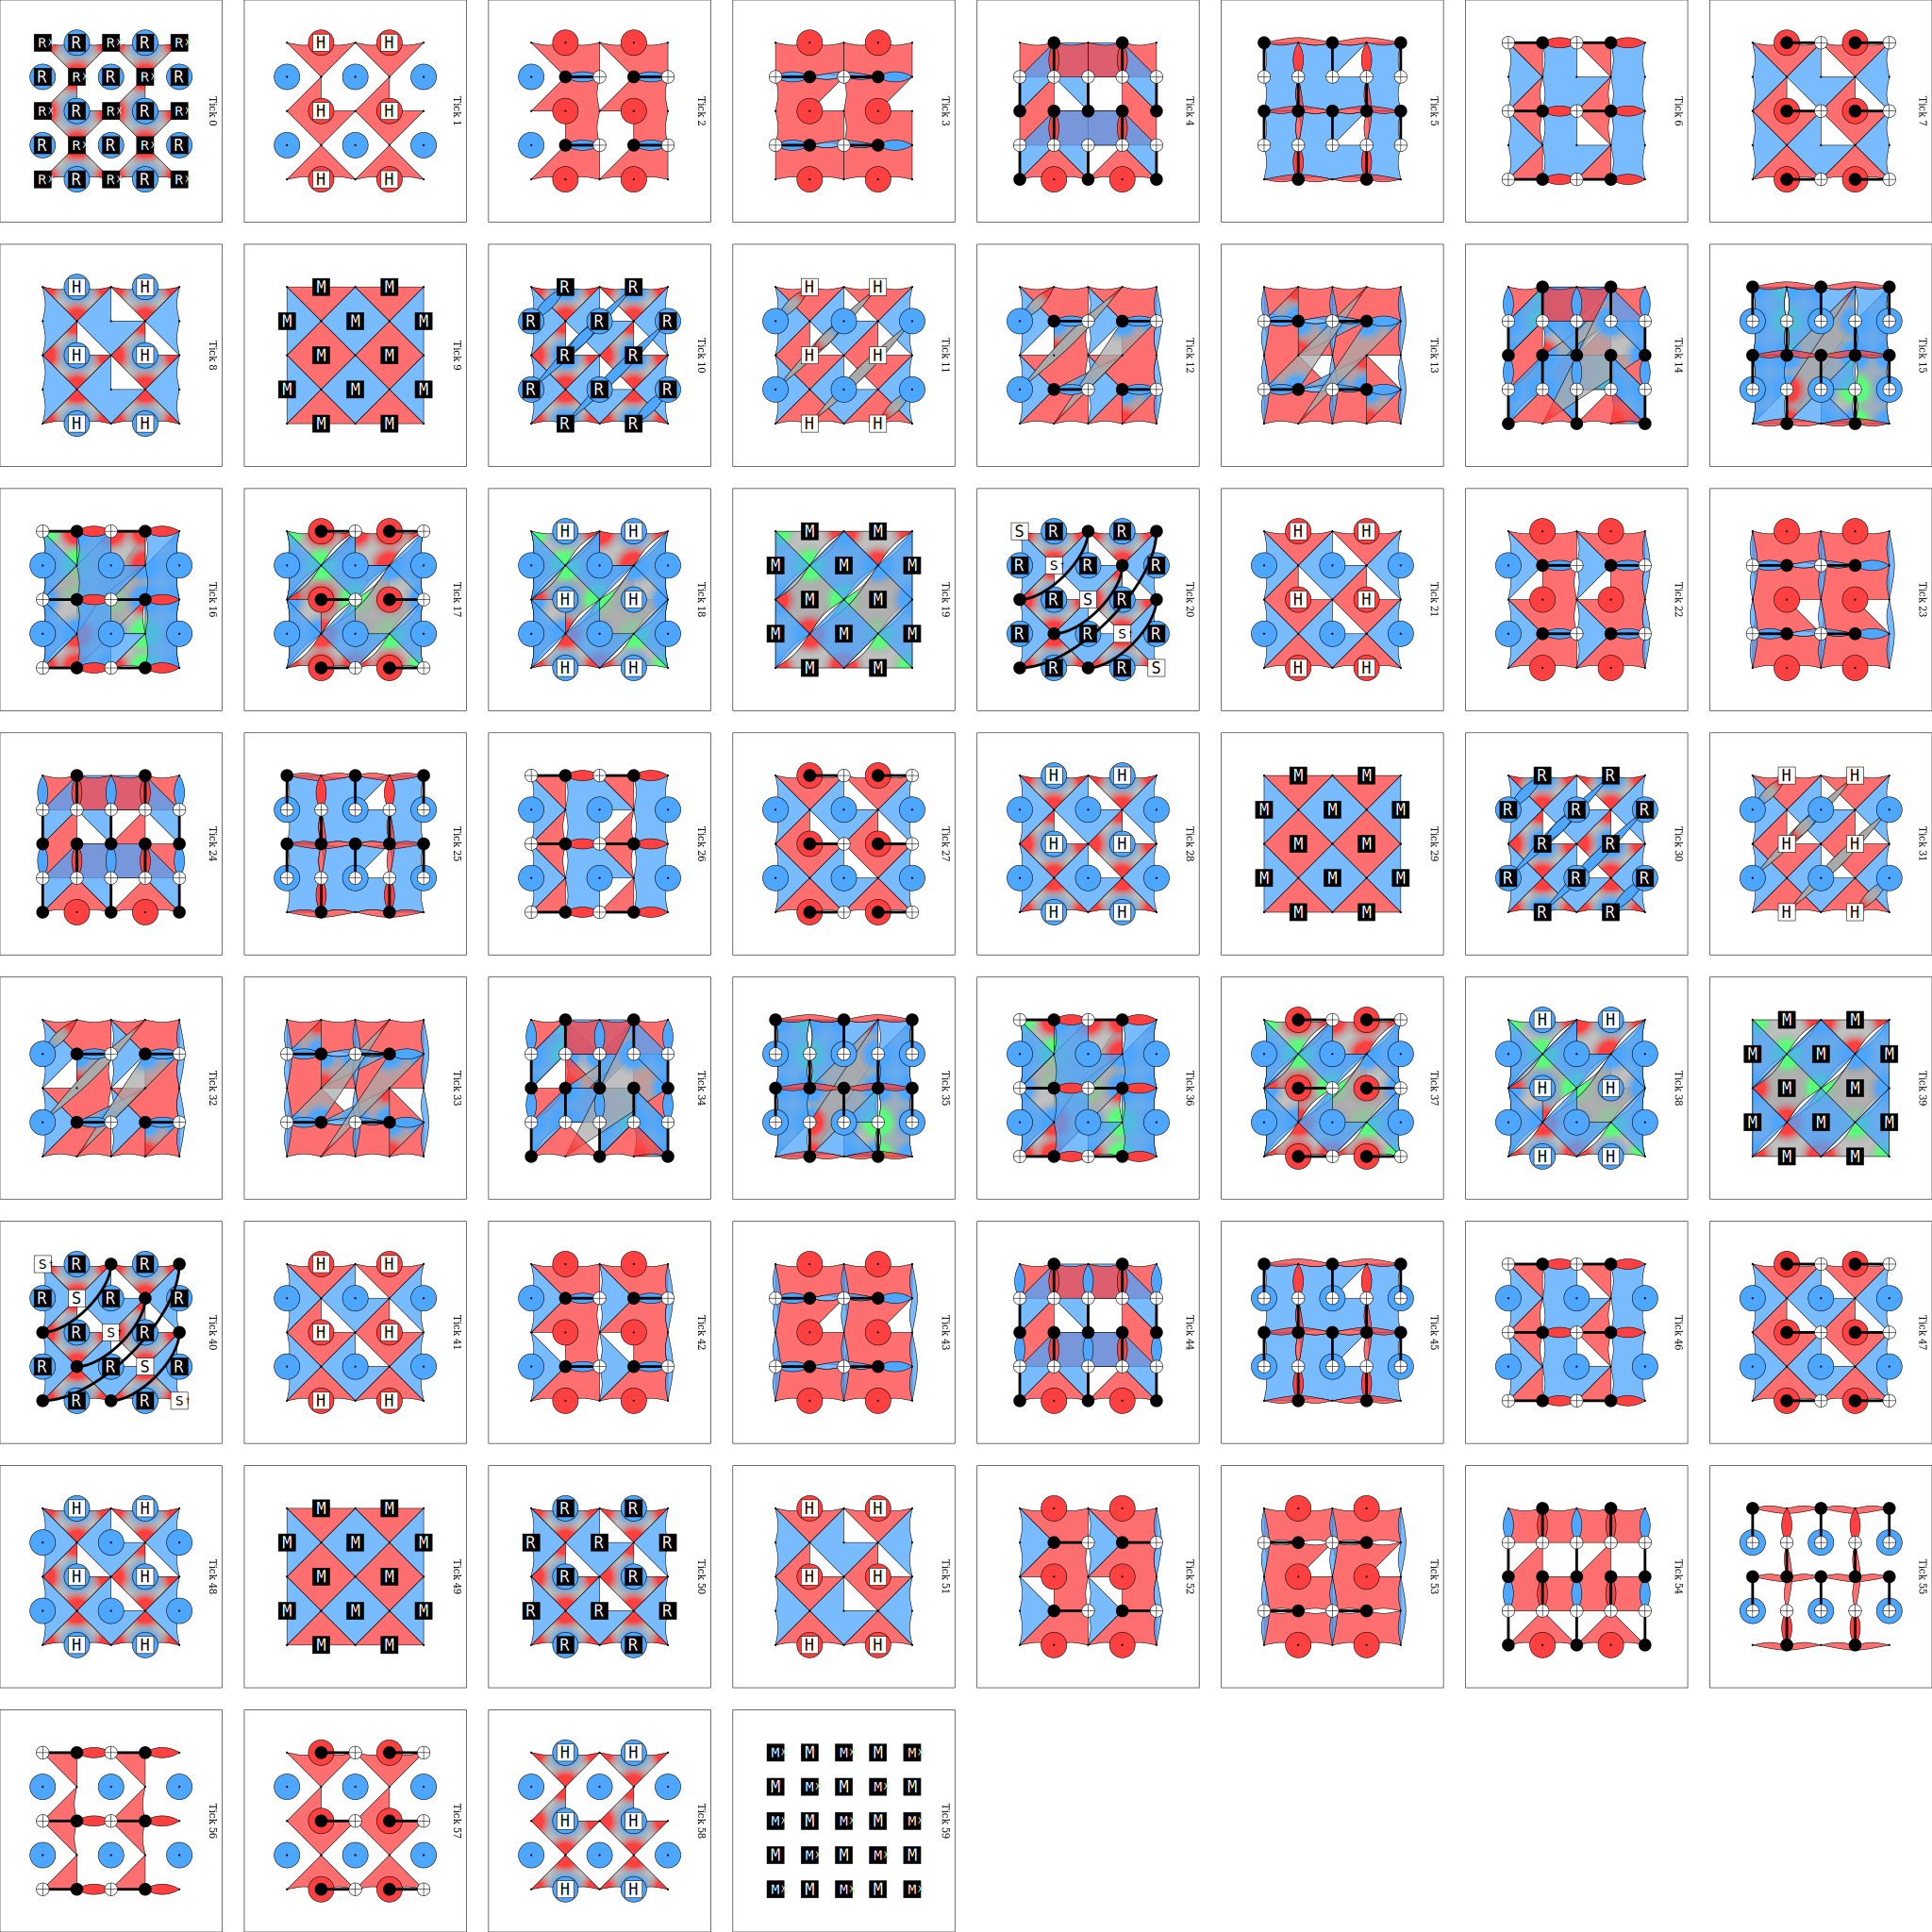

In [6]:
circuit_S.without_noise().diagram("detslice-with-ops-svg")

## 3. Noiseless Sanity Check

In [7]:
for label, circ in [
    ("H Z→X", circuit_H_ZtoX),
    ("H X→Z", circuit_H_XtoZ),
    ("S roundtrip", circuit_S),
]:
    sampler = circ.without_noise().compile_detector_sampler()
    det, obs = sampler.sample(shots=200, separate_observables=True)
    print(f"{label}: clean={not det.any() and not obs.any()}")

H Z→X: clean=True
H X→Z: clean=True
S roundtrip: clean=True


## 4. Simulation with BP+OSD (d=3, p=1e-3, 100k shots)

BP+OSD handles the non-CSS correlations introduced by H and S gates
(PyMatching can fail on these circuits).

In [8]:
pipeline = SimulationPipeline(
    decoder_config=DecoderConfig("bposd", backend="cpu"),
    max_shots=100_000,
    max_errors=50,
    num_workers=4,
    print_progress=False,
)

for label, circ in [
    ("H Z→X", circuit_H_ZtoX),
    ("H X→Z", circuit_H_XtoZ),
    ("S roundtrip", circuit_S),
]:
    stats = pipeline.run(circ)
    print(f"{label}: LER={stats.logical_error_rate:.2e}  ({stats.errors} errors / {stats.shots:,} shots)")

H Z→X: LER=1.20e-03  (96 errors / 80,000 shots)


H X→Z: LER=9.33e-04  (84 errors / 90,000 shots)


S roundtrip: LER=2.17e-03  (130 errors / 60,000 shots)
